In [2]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys 
import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Batching by alphabet

In [7]:
perm_20 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm20_nep20.pt")
perm_40 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm40_nep20.pt")
perm_60 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm60_nep20.pt")
perm_80 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm80_nep20.pt")
perm_100 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm100_nep20.pt")
perm_140 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm140_nep20.pt")
perm_200 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")
perm_400 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm400_nep20.pt")

all_training_runs = [perm_20, perm_40, perm_60, perm_80, perm_100, perm_140, perm_200, perm_400]

all_num_perm_alphs = [20,40,60,80,100,140,200,400]

In [58]:
# check that training alphabets have no overlap with new alphabets:
df20 = pd.read_csv("../data/all_transformations_study1_copy_perm20/train.csv")
df40 = pd.read_csv("../data/all_transformations_study1_copy_perm40/train.csv")
df60 = pd.read_csv("../data/all_transformations_study1_copy_perm60/train.csv")
df80 = pd.read_csv("../data/all_transformations_study1_copy_perm80/train.csv")
df100 = pd.read_csv("../data/all_transformations_study1_copy_perm100/train.csv")
df140 = pd.read_csv("../data/all_transformations_study1_copy_perm140/train.csv")
df200 = pd.read_csv("../data/all_transformations_study1_copy_perm200/train.csv")
df400 = pd.read_csv("../data/all_transformations_study1_copy_perm400/train.csv")

all_training_alphabets = set(
    list(df20.alphabet.unique()) + 
    list(df40.alphabet.unique()) + 
    list(df60.alphabet.unique()) + 
    list(df80.alphabet.unique()) +
    list(df100.alphabet.unique()) +
    list(df140.alphabet.unique()) +
    list(df200.alphabet.unique()) +
    list(df400.alphabet.unique())
    )

df_new_alphs = pd.read_csv("../data/all_transformations_study1_new_alphabets/test.csv")
# only overlapping alphabet should be the standard alphabet:
all_training_alphabets & set(df_new_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [61]:
import nltk

In [68]:
levenshtein_distances_by_dataset = []
for training_alphabets in [df20, df40, df60, df80, df100, df140, df200, df400]:
    min_levenshtein_distances = []
    for new_alph in df_new_alphs.alphabet.unique():
        min_levenshtein_dist = 1_000_000 # initialize with arbitrarily large number
        for train_alph in training_alphabets.alphabet.unique():
            levenshtein_dist = nltk.edit_distance(train_alph, new_alph)
            if levenshtein_dist < min_levenshtein_dist:
                min_levenshtein_dist = levenshtein_dist
        min_levenshtein_distances.append(min_levenshtein_dist)
    levenshtein_distances_by_dataset.append({
        "mean": np.mean(min_levenshtein_distances),
        "sd": np.std(min_levenshtein_distances)
    })

In [71]:
for perm_alphs, levenshtein_dist in zip(all_num_perm_alphs, levenshtein_distances_by_dataset):
    print(f"Training Dataset (with {perm_alphs} alphabets): Average minimum Levenshtein distance to new alphabets: {levenshtein_dist["mean"]:.2f} (sd: {levenshtein_dist["sd"]:.2f})")

Training Dataset (with 20 alphabets): Average minimum Levenshtein distance to new alphabets: 8.52 (sd: 6.64)
Training Dataset (with 40 alphabets): Average minimum Levenshtein distance to new alphabets: 8.38 (sd: 6.54)
Training Dataset (with 60 alphabets): Average minimum Levenshtein distance to new alphabets: 8.24 (sd: 6.61)
Training Dataset (with 80 alphabets): Average minimum Levenshtein distance to new alphabets: 8.19 (sd: 6.61)
Training Dataset (with 100 alphabets): Average minimum Levenshtein distance to new alphabets: 8.05 (sd: 6.48)
Training Dataset (with 140 alphabets): Average minimum Levenshtein distance to new alphabets: 7.86 (sd: 6.40)
Training Dataset (with 200 alphabets): Average minimum Levenshtein distance to new alphabets: 7.81 (sd: 6.43)
Training Dataset (with 400 alphabets): Average minimum Levenshtein distance to new alphabets: 7.71 (sd: 6.34)


In [11]:
# predictions on new set of permuted alphabets
accs_new_alphabets = pd.DataFrame(columns=["batching_method", "num. seen alphabets in training", "seen transform.", "new transform."])
for i, cp in enumerate(all_training_runs):
    test_new_alph = cp.load_dataloaders(
        "../data/all_transformations_study1_new_alphabets", 
        use_datasets=["test"],
        verbose=False)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.batching_method, all_num_perm_alphs[i], test_acc_in, test_acc_out_of]
accs_new_alphabets["alphabets"] = "new"
accs_new_alphabets

Predicting: 370it [07:13,  1.17s/it]                         
Predicting: 370it [04:26,  1.39it/s]                         
Predicting: 370it [05:39,  1.09it/s]                         
Predicting: 370it [10:46,  1.75s/it]                         
Predicting: 370it [10:34,  1.71s/it]                         
Predicting: 370it [07:38,  1.24s/it]                         
Predicting: 370it [12:51,  2.09s/it]                         
Predicting: 370it [11:20,  1.84s/it]                         


,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,alphabet,20,0.3045,0.034993,new
1,alphabet,40,0.526952,0.062103,new
2,alphabet,60,0.567022,0.053259,new
3,alphabet,80,0.704087,0.071332,new
4,alphabet,100,0.729846,0.068448,new
5,alphabet,140,0.98076,0.185541,new
6,alphabet,200,0.998728,0.262257,new
7,alphabet,400,0.815869,0.040185,new


In [22]:
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["seen transform."] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["new transform."] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
df = pd.DataFrame(data)
df["num. seen alphabets in training"] = [20, 40, 60, 80, 100, 140, 200, 400]
df["alphabets"] = "seen"

In [23]:
# Merge the two DataFrames on the 'perm. alphabets in training' column
df = df[["batching_method", "num. seen alphabets in training", "seen transform.", "new transform.", "alphabets"]]
all_accs = pd.concat([df, accs_new_alphabets])

In [24]:
all_accs

,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,alphabet,20,0.9,0.1,seen
1,alphabet,40,0.949,0.126,seen
2,alphabet,60,0.936,0.093,seen
3,alphabet,80,0.947,0.138,seen
4,alphabet,100,0.931,0.104,seen
5,alphabet,140,1.0,0.238,seen
6,alphabet,200,1.0,0.271,seen
7,alphabet,400,0.809,0.05,seen
0,alphabet,20,0.3045,0.034993,new
1,alphabet,40,0.526952,0.062103,new


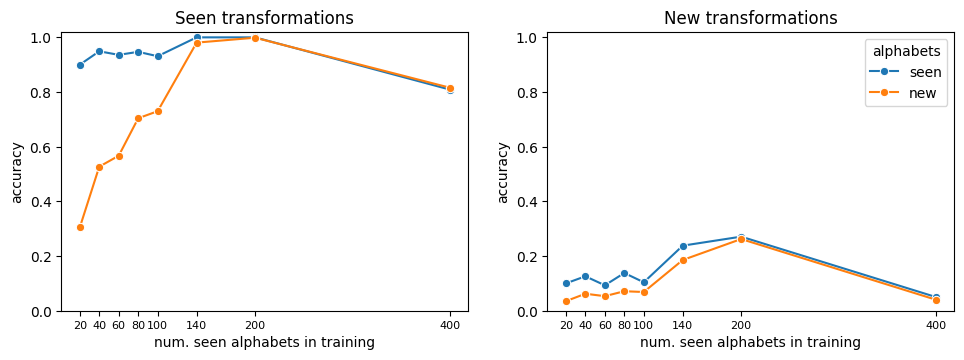

In [55]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[0].set_xticks([20, 40, 60, 80, 100, 140, 200, 400])
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen transformations")
_ = sns.lineplot(all_accs, 
                    x="num. seen alphabets in training", y="new transform.", 
                    hue="alphabets", 
                    markers=True, 
                    marker="o",
                    ax=ax[1])
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].set_title("New transformations")

_ = fig.tight_layout(pad=2)
_ = fig.subplots_adjust(hspace=0.3)

ax[0].tick_params(axis='x', labelsize=8)
ax[1].tick_params(axis='x', labelsize=8)

In [51]:
all_accs

,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,alphabet,20,0.9,0.1,seen
1,alphabet,40,0.949,0.126,seen
2,alphabet,60,0.936,0.093,seen
3,alphabet,80,0.947,0.138,seen
4,alphabet,100,0.931,0.104,seen
5,alphabet,140,1.0,0.238,seen
6,alphabet,200,1.0,0.271,seen
7,alphabet,400,0.809,0.05,seen
0,alphabet,20,0.3045,0.034993,new
1,alphabet,40,0.526952,0.062103,new


In [29]:
# Pivot the DataFrame
wide_df = all_accs.pivot_table(
    index="num. seen alphabets in training",
    columns="alphabets",
    values=["seen transform.", "new transform."]
)

# Swap levels so that the higher level is 'alphabet_type'
wide_df = wide_df.swaplevel(axis=1).sort_index(axis=1, level=0)

# Optional: flatten the columns if you want
# wide_df.columns = [' '.join(col).strip() for col in wide_df.columns.values]
wide_df = wide_df.round(3)
# Result: wide_df has a multi-level column index as you described
print(wide_df.to_latex())

\begin{tabular}{lllll}
\toprule
alphabets & \multicolumn{2}{r}{new} & \multicolumn{2}{r}{seen} \\
 & new transform. & seen transform. & new transform. & seen transform. \\
num. seen alphabets in training &  &  &  &  \\
\midrule
20 & 0.034993 & 0.304500 & 0.100000 & 0.900000 \\
40 & 0.062103 & 0.526952 & 0.126000 & 0.949000 \\
60 & 0.053259 & 0.567022 & 0.093000 & 0.936000 \\
80 & 0.071332 & 0.704087 & 0.138000 & 0.947000 \\
100 & 0.068448 & 0.729846 & 0.104000 & 0.931000 \\
140 & 0.185541 & 0.980760 & 0.238000 & 1.000000 \\
200 & 0.262257 & 0.998728 & 0.271000 & 1.000000 \\
400 & 0.040185 & 0.815869 & 0.050000 & 0.809000 \\
\bottomrule
\end{tabular}



In [30]:
wide_df

alphabets                                  new                           seen  \
                                new transform. seen transform. new transform.   
num. seen alphabets in training                                                 
20                                    0.034993          0.3045            0.1   
40                                    0.062103        0.526952          0.126   
60                                    0.053259        0.567022          0.093   
80                                    0.071332        0.704087          0.138   
100                                   0.068448        0.729846          0.104   
140                                   0.185541         0.98076          0.238   
200                                   0.262257        0.998728          0.271   
400                                   0.040185        0.815869           0.05   

alphabets                                        
                                seen transform.  
num. seen alphabets in training                  
20                                          0.9  
40                                        0.949  
60                                        0.936  
80                                        0.947  
100                                       0.931  
140                                         1.0  
200                                         1.0  
400                                       0.809

### Random Batching

In [31]:
perm_20 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm20_nep20.pt")
perm_40 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm40_nep20.pt")
perm_60 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm60_nep20.pt")
perm_80 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm80_nep20.pt")
perm_100 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm100_nep20.pt")
perm_140 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm140_nep20.pt")
perm_200 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm200_nep20.pt")
perm_400 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm400_nep20.pt")

all_training_runs_batch_random = [perm_20, perm_40, perm_60, perm_80, perm_100, perm_140, perm_200, perm_400]

In [ ]:
alphabets_in_training = [20, 40, 60, 80, 100, 140, 200, 400]
# predictions on new set of permuted alphabets
accs_new_alphabets_batch_random = pd.DataFrame(columns=["batching method", "num. seen alphabets in training", "seen transform.", "new transform."])
for i, cp in enumerate(all_training_runs_batch_random):
    test_new_alph = cp.load_dataloaders(
        "../data/all_transformations_study1_new_alphabets", 
        use_datasets=["test"],
        verbose=False)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = round(np.mean(pred[pred.distribution == "in"]["correct"]), 3)
    test_acc_out_of = round(np.mean(pred[pred.distribution == "out-of"]["correct"]), 3)
    accs_new_alphabets_batch_random.loc[i,:] = [cp.train_config.batching_method, alphabets_in_training[i], test_acc_in, test_acc_out_of]
accs_new_alphabets_batch_random["alphabets"] = "new"
accs_new_alphabets_batch_random.round(3)

Predicting: 360it [04:18,  1.40it/s]                         
Predicting: 360it [07:07,  1.19s/it]                         
Predicting: 360it [13:08,  2.19s/it]                         
Predicting: 360it [15:05,  2.51s/it]                          
Predicting: 360it [09:50,  1.64s/it]                         
Predicting: 360it [06:30,  1.08s/it]                         
Predicting: 360it [09:58,  1.66s/it]                         
Predicting: 360it [11:29,  1.92s/it]                         


,batching method,num. seen alphabets in training,seen transform.,new transform.
0,random,20,0.362,0.039
1,random,40,0.48,0.057
2,random,60,0.621,0.064
3,random,80,0.702,0.065
4,random,100,0.969,0.252
5,random,140,0.765,0.047
6,random,200,0.995,0.096
7,random,400,0.999,0.109


In [42]:
accs_new_alphabets_batch_random["alphabets"] = "new"

In [48]:
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs_batch_random]
for i, train_run in enumerate(all_training_runs_batch_random):
    data[i]["seen transform."] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["new transform."] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
    data[i]["batching method"] = train_run.train_config.batching_method
accs_seen_alphabets_batch_random = pd.DataFrame(data)
accs_seen_alphabets_batch_random["num. seen alphabets in training"] = [20, 40, 60, 80, 100, 140, 200, 400]
accs_seen_alphabets_batch_random = accs_seen_alphabets_batch_random[["batching method", "num. seen alphabets in training", "seen transform.","new transform."]]
accs_seen_alphabets_batch_random["alphabets"] = "seen"

In [49]:
# Merge the two DataFrames on the 'perm. alphabets in training' column
all_accs_batchrand = pd.concat([accs_seen_alphabets_batch_random, accs_new_alphabets_batch_random])

In [46]:
accs_new_alphabets_batch_random

,batching method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,random,20,0.362,0.039,new
1,random,40,0.48,0.057,new
2,random,60,0.621,0.064,new
3,random,80,0.702,0.065,new
4,random,100,0.969,0.252,new
5,random,140,0.765,0.047,new
6,random,200,0.995,0.096,new
7,random,400,0.999,0.109,new


In [47]:
accs_seen_alphabets_batch_random

,batching method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,random,20,90.1,9.9,seen
1,random,40,91.8,11.1,seen
2,random,60,94.4,11.9,seen
3,random,80,95.1,11.6,seen
4,random,100,100.0,28.7,seen
5,random,140,91.3,7.6,seen
6,random,200,99.9,14.3,seen
7,random,400,100.0,14.4,seen


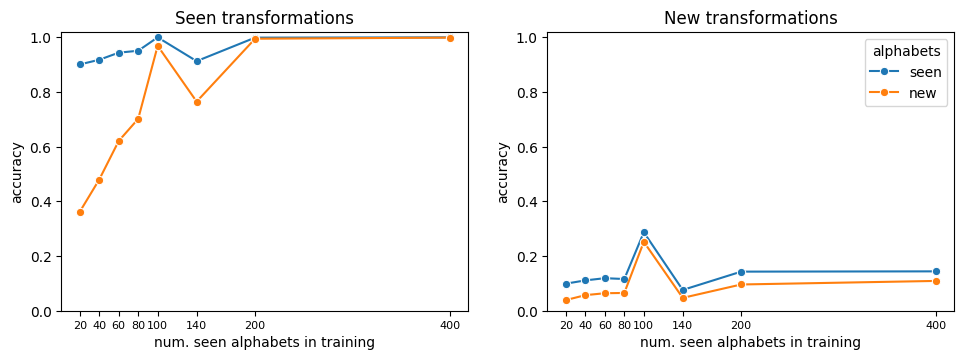

In [56]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs_batchrand, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[0].set_xticks([20, 40, 60, 80, 100, 140, 200, 400])
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen transformations")
_ = sns.lineplot(all_accs_batchrand, 
                    x="num. seen alphabets in training", y="new transform.", 
                    hue="alphabets", 
                    markers=True, 
                    marker="o",
                    ax=ax[1])
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].legend(title="alphabets", loc='upper right')
_ = ax[1].set_title("New transformations")

_ = fig.tight_layout(pad=2)
_ = fig.subplots_adjust(hspace=0.3)
ax[0].tick_params(axis='x', labelsize=8)
ax[1].tick_params(axis='x', labelsize=8)

In [ ]:
all_accs["batching_method"] = "random"
all_accs

,accuracy in-dist,accuracy out-of-dist,perm. alphabets in training,new_alphabets,batching_method
0,0.901,0.099,20,False,random
1,0.918,0.111,40,False,random
2,0.944,0.119,60,False,random
3,0.951,0.116,80,False,random
4,1.0,0.287,100,False,random
5,0.913,0.076,140,False,random
6,0.999,0.143,200,False,random
7,1.0,0.144,400,False,random
0,0.362061,0.038646,20,True,random
1,0.479727,0.057104,40,True,random


In [ ]:
# Create a new column for the higher-level index
all_accs['alphabet_type'] = all_accs['new_alphabets'].map({False: 'seen alphabets', True: 'new alphabets'})

# Pivot the DataFrame
wide_df = all_accs.pivot_table(
    index="perm. alphabets in training",
    columns="alphabet_type",
    values=["accuracy in-dist", "accuracy out-of-dist"]
)

# Swap levels so that the higher level is 'alphabet_type'
wide_df = wide_df.swaplevel(axis=1).sort_index(axis=1, level=0)

# Optional: flatten the columns if you want
# wide_df.columns = [' '.join(col).strip() for col in wide_df.columns.values]
wide_df = wide_df.round(3)
# Result: wide_df has a multi-level column index as you described
print(wide_df.to_latex())

\begin{tabular}{lllll}
\toprule
alphabet_type & \multicolumn{2}{r}{new alphabets} & \multicolumn{2}{r}{seen alphabets} \\
 & accuracy in-dist & accuracy out-of-dist & accuracy in-dist & accuracy out-of-dist \\
perm. alphabets in training &  &  &  &  \\
\midrule
20 & 0.362061 & 0.038646 & 0.901000 & 0.099000 \\
40 & 0.479727 & 0.057104 & 0.918000 & 0.111000 \\
60 & 0.621084 & 0.064218 & 0.944000 & 0.119000 \\
80 & 0.702337 & 0.065372 & 0.951000 & 0.116000 \\
100 & 0.969152 & 0.252067 & 1.000000 & 0.287000 \\
140 & 0.765304 & 0.047299 & 0.913000 & 0.076000 \\
200 & 0.994594 & 0.096328 & 0.999000 & 0.143000 \\
400 & 0.999205 & 0.108633 & 1.000000 & 0.144000 \\
\bottomrule
\end{tabular}

